<a href="https://colab.research.google.com/github/eetyiop/computational-physics-housing-project/blob/main/housing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_housing_project_data.xlsx to cleaned_housing_project_data (1).xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

file_name = "cleaned_housing_project_data.xlsx"

xls = pd.ExcelFile(file_name)
xls.sheet_names

['README',
 'Population_Trend',
 'Population_Region_2015_2024',
 'Price_Index_2015_2024',
 'Merged_2015_2024',
 'National_2015_2024',
 'Regional_Change_2015_2024']

In [4]:
pop_trend = pd.read_excel(file_name, sheet_name="Population_Trend")
merged = pd.read_excel(file_name, sheet_name="Merged_2015_2024")
regional_change = pd.read_excel(file_name, sheet_name="Regional_Change_2015_2024")

print("Population trend:", pop_trend.shape)
print("Merged data:", merged.shape)
print("Regional change:", regional_change.shape)

display(pop_trend.head())
display(merged.head())
display(regional_change.head())

Population trend: (12, 7)
Merged data: (170, 11)
Regional change: (17, 11)


,Year,Region,Total_Population,Korean_Population,Foreign_Population,General_Households,Apartment_Count
0,2005,전국,47278951,47041434,237517,15887128,6962689
1,2010,전국,48580293,47990761,589532,17339422,8576013
2,2015,전국,51069375,49705663,1363712,19111030,9806062
3,2016,전국,51269554,49855796,1413758,19367696,10029644
4,2017,전국,51422507,49943260,1479247,19673875,10375363


,Year,Region,Total_Population,Korean_Population,Foreign_Population,General_Households,Apartment_Count,Korean_Population_Million,General_Households_Million,Apartment_Price_Index,Weeks_Used
0,2015,서울,9904312,9567196,337116,3784490,1636896,9.567196,3.784490,73.9519,52
1,2015,부산,3448737,3404667,44070,1335900,738068,3.404667,1.335900,95.5040,52
2,2015,대구,2466052,2436770,29282,928528,509068,2.436770,0.928528,112.2133,52
3,2015,인천,2890451,2822601,67850,1045417,577346,2.822601,1.045417,83.7160,52
4,2015,광주,1502881,1481289,21592,567157,376731,1.481289,0.567157,93.3154,52


,Region,Korean_Population_Change_Pct,General_Households_Change_Pct,Apartment_Price_Index_Change_Pct,Apartment_Price_Index_Change_Point,Pop_2015,Pop_2024,Households_2015,Households_2024,Price_Index_2015,Price_Index_2024
0,서울,-6.2614,9.9092,19.3834,14.3344,9567196,8968153,3784490,4159502,73.9519,88.2863
1,부산,-6.3199,10.0802,6.9868,6.6727,3404667,3189494,1335900,1470562,95.5040,102.1767
2,대구,-4.6262,12.4068,-4.8159,-5.4041,2436770,2324040,928528,1043729,112.2133,106.8092
3,인천,3.8076,21.3040,19.1414,16.0244,2822601,2930073,1045417,1268133,83.7160,99.7404
4,광주,-4.9281,10.8249,10.1228,9.4461,1481289,1408289,567157,628551,93.3154,102.7615


In [5]:
os.makedirs("figures", exist_ok=True)

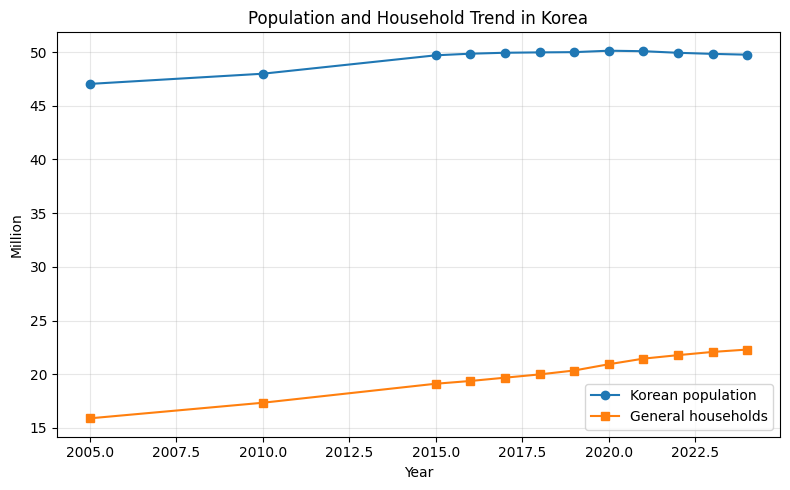

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    pop_trend["Year"],
    pop_trend["Korean_Population"] / 1_000_000,
    marker="o",
    label="Korean population"
)

plt.plot(
    pop_trend["Year"],
    pop_trend["General_Households"] / 1_000_000,
    marker="s",
    label="General households"
)

plt.xlabel("Year")
plt.ylabel("Million")
plt.title("Population and Household Trend in Korea")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("figures/01_population_trend.png", dpi=300)
plt.show()

Correlation: population change vs price index change = 0.191
Correlation: household change vs price index change = 0.203


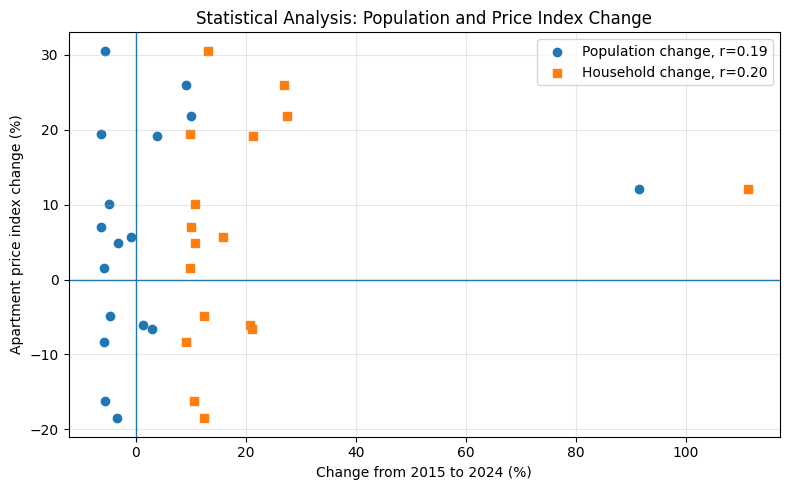

In [9]:
corr_pop = regional_change["Korean_Population_Change_Pct"].corr(
    regional_change["Apartment_Price_Index_Change_Pct"]
)

corr_house = regional_change["General_Households_Change_Pct"].corr(
    regional_change["Apartment_Price_Index_Change_Pct"]
)

print("Correlation: population change vs price index change =", round(corr_pop, 3))
print("Correlation: household change vs price index change =", round(corr_house, 3))

plt.figure(figsize=(8, 5))

plt.scatter(
    regional_change["Korean_Population_Change_Pct"],
    regional_change["Apartment_Price_Index_Change_Pct"],
    label=f"Population change, r={corr_pop:.2f}"
)

plt.scatter(
    regional_change["General_Households_Change_Pct"],
    regional_change["Apartment_Price_Index_Change_Pct"],
    marker="s",
    label=f"Household change, r={corr_house:.2f}"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Change from 2015 to 2024 (%)")
plt.ylabel("Apartment price index change (%)")
plt.title("Statistical Analysis: Population and Price Index Change")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("figures/02_statistical_analysis.png", dpi=300)
plt.show()

Fitting equation: Price Index = 4.034 * Households(million) + 13.712
R-squared = 0.521


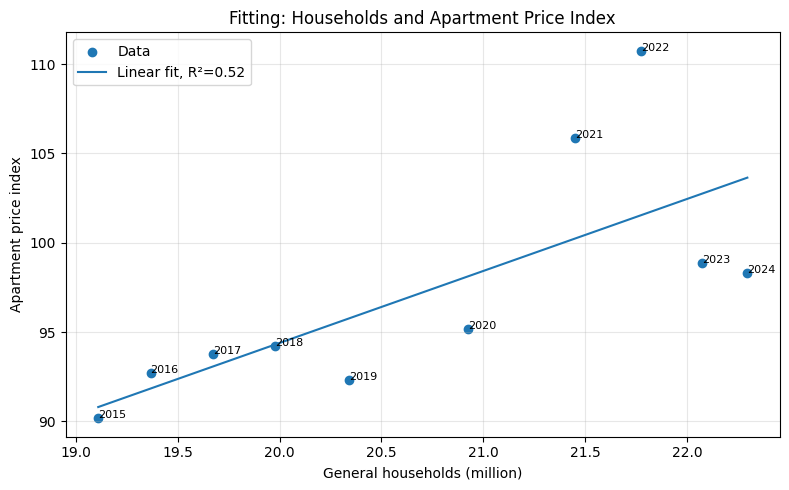

In [10]:
national = pd.read_excel(file_name, sheet_name="National_2015_2024")

x = national["General_Households"] / 1_000_000   # million households
y = national["Apartment_Price_Index"]

# Linear fitting: y = a*x + b
a, b = np.polyfit(x, y, 1)
y_fit = a * x + b

# R-squared
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print("Fitting equation: Price Index = {:.3f} * Households(million) + {:.3f}".format(a, b))
print("R-squared =", round(r2, 3))

plt.figure(figsize=(8, 5))

plt.scatter(x, y, label="Data")
plt.plot(x, y_fit, label=f"Linear fit, R²={r2:.2f}")

for i in range(len(national)):
    plt.text(x.iloc[i], y.iloc[i], str(national["Year"].iloc[i]), fontsize=8)

plt.xlabel("General households (million)")
plt.ylabel("Apartment price index")
plt.title("Fitting: Households and Apartment Price Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("figures/03_fitting.png", dpi=300)
plt.show()

Mean annual household growth rate = 0.01728
Std of annual household growth rate = 0.00557
2045 median predicted apartment price index = 142.52
68% range = 139.35 ~ 145.9


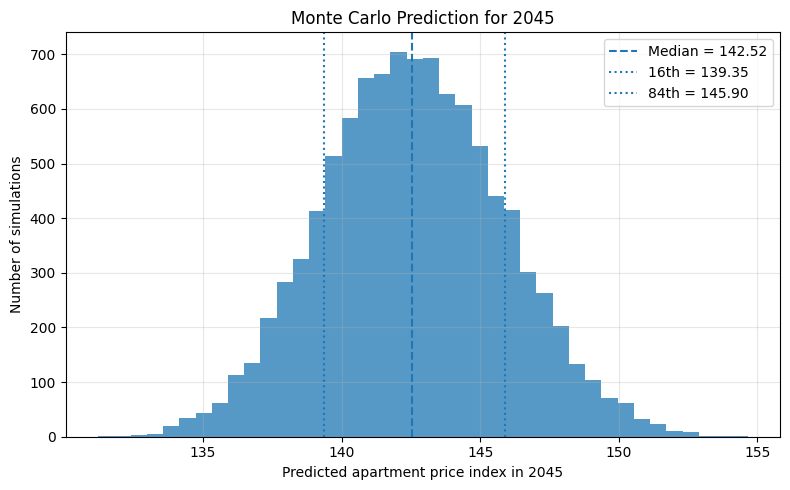

In [11]:
np.random.seed(42)

# Historical annual growth rate of general households
households = national["General_Households"].values
years = national["Year"].values

growth_rates = households[1:] / households[:-1] - 1

mu = np.mean(growth_rates)
sigma = np.std(growth_rates)

print("Mean annual household growth rate =", round(mu, 5))
print("Std of annual household growth rate =", round(sigma, 5))

# Monte Carlo settings
n_sim = 10000
start_households = households[-1]  # 2024 value
future_years = 2045 - 2024

final_price_index = []

for _ in range(n_sim):
    h = start_households

    for _ in range(future_years):
        random_growth = np.random.normal(mu, sigma)
        h = h * (1 + random_growth)

    h_million = h / 1_000_000
    predicted_price = a * h_million + b
    final_price_index.append(predicted_price)

final_price_index = np.array(final_price_index)

median_pred = np.median(final_price_index)
lower_pred = np.percentile(final_price_index, 16)
upper_pred = np.percentile(final_price_index, 84)

print("2045 median predicted apartment price index =", round(median_pred, 2))
print("68% range =", round(lower_pred, 2), "~", round(upper_pred, 2))

plt.figure(figsize=(8, 5))

plt.hist(final_price_index, bins=40, alpha=0.75)

plt.axvline(median_pred, linestyle="--", label=f"Median = {median_pred:.2f}")
plt.axvline(lower_pred, linestyle=":", label=f"16th = {lower_pred:.2f}")
plt.axvline(upper_pred, linestyle=":", label=f"84th = {upper_pred:.2f}")

plt.xlabel("Predicted apartment price index in 2045")
plt.ylabel("Number of simulations")
plt.title("Monte Carlo Prediction for 2045")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("figures/04_monte_carlo.png", dpi=300)
plt.show()